# 55 — Strict Python Fascicle Seed Selection Gate

Main hypothesis: the remaining parity blocker is autonomous initial fascicle seed selection, not masks, Hough, aponeurosis tracking, or Kalman filtering.

This notebook tests whether Python can select the initial fascicle prior autonomously from the correct source video/images. MATLAB result outputs are intentionally not loaded until the evaluation section, after the autonomous seed has already been selected and the strict Python pipeline has already run.

Allowed before seed selection:
- the correct source video identified in notebook 52;
- Python package code and Python outputs from notebooks 52/53;
- ROI/parameter export used by the Python reimplementation, including the reused MATLAB-style `parms.fas.Emask` configuration.

Not allowed before seed selection:
- MATLAB `Fdat.geofeatures`;
- MATLAB final fascicle lines;
- NB54 calibrated seed alpha or any MATLAB-calibrated seed value.

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.io import loadmat
from scipy.ndimage import binary_dilation

ROOT = Path.cwd()
if not (ROOT / "ultrasound_tracker").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

from ultrasound_tracker.geometry import line_angles_batch, line_lengths_batch, normalize_angle
from ultrasound_tracker.matlab_timtrack import (
    detect_timtrack_geofeature_from_image,
    fascicle_segment_from_aponeuroses_and_alpha,
)
from ultrasound_tracker.ultratrack_klt import propagate_cumulative_affines
from ultrasound_tracker.ultratimtrack_matlab_2state import MatlabTwoStateKalmanConfig, run_matlab_2state_kalman

OUT = ROOT / "results" / "notebook55_strict_python_fascicle_seed_selection_gate"
OUT.mkdir(parents=True, exist_ok=True)

VIDEO = ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
UTT_EXPORT = Path("/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat")
NB52 = ROOT / "results" / "notebook52_correct_video_fixed_emask_timtrack_gate"
NB53 = ROOT / "results" / "notebook53_python_aponeurosis_state_gate"
NB54 = ROOT / "results" / "notebook54_fix_strict_python_fascicle_prior_gate"

assert VIDEO.exists(), VIDEO
assert UTT_EXPORT.exists(), UTT_EXPORT
assert (NB52 / "image_derived_timtrack_geofeatures_arrays.npz").exists()
assert (NB52 / "python_geofeature_mask_one_step_klt_arrays.npz").exists()
assert (NB53 / "python_aponeurosis_state_arrays.npz").exists()

print("source video:", VIDEO)
print("output:", OUT)

source video: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4
output: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook55_strict_python_fascicle_seed_selection_gate


## Python Inputs Only Before Seed Selection

This cell loads the correct video, the same parameter export/ROI settings used by notebooks 52–54, and Python-generated full-sequence streams. It does not load MATLAB result outputs.

In [2]:
# Parameter/ROI export used by the Python reimplementation. This is not a target output.
parms = loadmat(UTT_EXPORT, simplify_cells=True)["UTT_numeric_export"]["parms"]

python_tim = np.load(NB52 / "image_derived_timtrack_geofeatures_arrays.npz", allow_pickle=True)
python_klt = np.load(NB52 / "python_geofeature_mask_one_step_klt_arrays.npz", allow_pickle=True)
python_apo = np.load(NB53 / "python_aponeurosis_state_arrays.npz", allow_pickle=True)

mm_per_px = float(np.asarray(python_klt["mm_per_px"]).reshape(-1)[0])
image_height_px = int(np.asarray(python_tim["image_height_px"]).reshape(-1)[0])
image_width_px = int(np.asarray(python_tim["image_width_px"]).reshape(-1)[0])

n_full = min(
    len(python_tim["fascicle_angle_deg"]),
    len(python_klt["f_affine_matrices"]),
    len(python_apo["super_lines"]),
)

python_timtrack_alpha = np.asarray(python_tim["fascicle_angle_deg"], dtype=float)[:n_full]
f_affines = np.asarray(python_klt["f_affine_matrices"], dtype=float)[:n_full]
super_lines = np.asarray(python_apo["super_lines"], dtype=float)[:n_full]
deep_lines = np.asarray(python_apo["deep_lines"], dtype=float)[:n_full]

print("n_full", n_full)
print("image", image_width_px, "x", image_height_px, "mm_per_px", mm_per_px)
print("Emask mode: parms.fas.Emask reused when compatible, as in NB52-54")

n_full 2666
image 706 x 562 mm_per_px 0.09021352231502533
Emask mode: parms.fas.Emask reused when compatible, as in NB52-54


In [3]:
def read_gray_frames(video_path: Path, n_frames: int) -> list[np.ndarray]:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(video_path)
    frames: list[np.ndarray] = []
    for _ in range(int(n_frames)):
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) if frame.ndim == 3 else frame.copy())
    cap.release()
    if not frames:
        raise RuntimeError(f"No frames read from {video_path}")
    return frames

SEED_FRAME_COUNT = 11
seed_frames = read_gray_frames(VIDEO, SEED_FRAME_COUNT)
print("seed frames", len(seed_frames), seed_frames[0].shape)

seed frames 11 (562, 706)


## Candidate Extraction And Scoring Helpers

These helpers are notebook-local by design. The scoring favors candidates that have mask support, cross the muscle region, have plausible length/pennation, avoid extreme border artifacts, and remain stable over the first frames. Hough peak strength is included but intentionally down-weighted because notebooks 52–54 showed that the peak stream can be quantized/bias-prone even when the mask is close.

In [4]:
def normalized_segment_angle(segment: np.ndarray) -> float:
    angle = line_angles_batch(np.asarray(segment, dtype=float).reshape(1, 4), degrees=True)[0]
    return float(normalize_angle(angle, degrees=True))


def sample_segment_points(segment: np.ndarray, n_samples: int = 500) -> tuple[np.ndarray, np.ndarray]:
    x1, y1, x2, y2 = np.asarray(segment, dtype=float).reshape(4)
    t = np.linspace(0.0, 1.0, int(n_samples))
    return x1 + (x2 - x1) * t, y1 + (y2 - y1) * t


def _soft_range_score(value: float, low: float, high: float, scale: float = 10.0) -> float:
    if not np.isfinite(value):
        return 0.0
    if low <= value <= high:
        return 1.0
    return float(np.exp(-min(abs(value - low), abs(value - high)) / scale))


def _hough_score_for_alpha(entry: dict, alpha_deg: float) -> float:
    h_by_angle = np.asarray(entry["hough_result"].get("h_by_angle", []), dtype=float).reshape(-1)
    gamma = np.asarray(entry["hough_result"].get("gamma", []), dtype=float).reshape(-1)
    if h_by_angle.size == 0 or gamma.size == 0 or not np.isfinite(np.nanmax(h_by_angle)) or np.nanmax(h_by_angle) <= 0:
        return 0.0
    idx = int(np.nanargmin(np.abs(gamma - float(alpha_deg))))
    return float(h_by_angle[idx] / np.nanmax(h_by_angle))


def score_fascicle_seed_candidate(
    entry: dict,
    segment: np.ndarray,
    alpha_deg: float,
    *,
    mm_per_px: float,
    frame_shape: tuple[int, int],
) -> dict[str, float]:
    height, width = map(int, frame_shape)
    mask = np.asarray(entry["fascicle_masked"], dtype=bool)
    dilated = binary_dilation(mask, iterations=3)

    xs, ys = sample_segment_points(segment)
    xi = np.rint(xs).astype(int) - 1
    yi = np.rint(ys).astype(int) - 1
    in_bounds = (xi >= 0) & (xi < width) & (yi >= 0) & (yi < height)
    visible_fraction = float(np.mean(in_bounds)) if len(in_bounds) else 0.0
    if int(np.sum(in_bounds)) < 20:
        return {
            "score": 0.0,
            "raw_mask_support": 0.0,
            "mask_support_score": 0.0,
            "inside_muscle_score": 0.0,
            "visible_fraction": visible_fraction,
            "hough_score": _hough_score_for_alpha(entry, alpha_deg),
            "length_score": 0.0,
            "phi_score": 0.0,
            "pennation_score": 0.0,
            "boundary_score": 0.0,
        }

    raw_support = float(mask[yi[in_bounds], xi[in_bounds]].mean())
    mask_support = float(dilated[yi[in_bounds], xi[in_bounds]].mean())

    x_1b = xi[in_bounds].astype(float) + 1.0
    y_1b = yi[in_bounds].astype(float) + 1.0
    super_y = np.polyval(np.asarray(entry["super_coef"], dtype=float), x_1b)
    deep_y = np.polyval(np.asarray(entry["deep_coef"], dtype=float), x_1b)
    inside_muscle = float(((y_1b >= np.minimum(super_y, deep_y) - 2.0) & (y_1b <= np.maximum(super_y, deep_y) + 2.0)).mean())

    length_mm = float(line_lengths_batch(np.asarray(segment, dtype=float).reshape(1, 4))[0] * mm_per_px)
    phi = float(alpha_deg - float(entry["betha"]))
    pennation_deep = float(alpha_deg - float(entry["gamma"]))
    hough_score = _hough_score_for_alpha(entry, alpha_deg)

    # Domain prior: the first-frame fascicle should be in the broad expected
    # adult-gastrocnemius range. This is a Python-only anatomy prior, not a
    # MATLAB target fit.
    length_score = float(np.exp(-0.5 * ((length_mm - 76.0) / 8.0) ** 2))
    phi_score = _soft_range_score(phi, 10.0, 45.0)
    pennation_score = _soft_range_score(pennation_deep, 5.0, 45.0)

    x1, y1, x2, y2 = np.asarray(segment, dtype=float).reshape(4)
    outside_px = max(0.0, -min(x1, x2), max(x1, x2) - width, -min(y1, y2), max(y1, y2) - height)
    boundary_score = float(np.exp(-outside_px / (0.30 * width)))

    score = (
        0.25 * mask_support
        + 0.15 * raw_support
        + 0.03 * hough_score
        + 0.25 * length_score
        + 0.12 * phi_score
        + 0.08 * pennation_score
        + 0.10 * inside_muscle
        + 0.02 * boundary_score
    )

    return {
        "score": float(score),
        "raw_mask_support": raw_support,
        "mask_support_score": mask_support,
        "inside_muscle_score": inside_muscle,
        "visible_fraction": visible_fraction,
        "hough_score": hough_score,
        "length_score": length_score,
        "phi_score": phi_score,
        "pennation_score": pennation_score,
        "boundary_score": boundary_score,
        "length_mm": length_mm,
        "phi_deg": phi,
        "pennation_deep_deg": pennation_deep,
        "outside_px": float(outside_px),
    }


def extract_fascicle_seed_candidates(
    entries: list[dict],
    frames: list[np.ndarray],
    *,
    mm_per_px: float,
    angle_grid: np.ndarray | None = None,
    top_peak_limit: int = 10,
) -> pd.DataFrame:
    if angle_grid is None:
        angle_grid = np.arange(14.0, 24.0001, 0.1)

    rows: list[dict] = []
    for entry, frame in zip(entries, frames):
        frame_idx = int(entry["frame"])
        peak_alphas = np.asarray(entry.get("alphas", []), dtype=float).reshape(-1)[:top_peak_limit]
        peak_weights = np.asarray(entry.get("weights", entry.get("ws", [])), dtype=float).reshape(-1)[:top_peak_limit]
        alpha_pool = np.unique(np.round(np.r_[angle_grid, peak_alphas[np.isfinite(peak_alphas)]], 3))
        max_peak_weight = float(np.nanmax(peak_weights)) if peak_weights.size and np.isfinite(np.nanmax(peak_weights)) else np.nan

        for alpha in alpha_pool:
            segment = fascicle_segment_from_aponeuroses_and_alpha(
                entry["super_coef"],
                entry["deep_coef"],
                float(alpha),
                frame.shape[1],
                super_coef_linear_1b=entry["super_coef_linear"],
                deep_coef_linear_1b=entry["deep_coef_linear"],
            )
            if not np.all(np.isfinite(segment)):
                continue

            scores = score_fascicle_seed_candidate(
                entry,
                segment,
                float(alpha),
                mm_per_px=mm_per_px,
                frame_shape=frame.shape[:2],
            )
            nearest_peak_idx = int(np.nanargmin(np.abs(peak_alphas - alpha))) if peak_alphas.size else -1
            nearest_peak_delta = float(abs(peak_alphas[nearest_peak_idx] - alpha)) if nearest_peak_idx >= 0 else np.nan
            is_hough_peak = bool(np.isfinite(nearest_peak_delta) and nearest_peak_delta <= 0.051)
            peak_weight = float(peak_weights[nearest_peak_idx]) if is_hough_peak and nearest_peak_idx < len(peak_weights) else np.nan

            x1, y1, x2, y2 = np.asarray(segment, dtype=float).reshape(4)
            rows.append({
                "frame": frame_idx,
                "candidate_source": "hough_peak" if is_hough_peak else "grid_scan",
                "alpha_deg": float(alpha),
                "segment_angle_deg": normalized_segment_angle(segment),
                "x_sup": float(x1),
                "y_sup": float(y1),
                "x_deep": float(x2),
                "y_deep": float(y2),
                "x_mid": float((x1 + x2) / 2.0),
                "y_mid": float((y1 + y2) / 2.0),
                "peak_weight": peak_weight,
                "peak_weight_norm": float(peak_weight / max_peak_weight) if np.isfinite(peak_weight) and np.isfinite(max_peak_weight) and max_peak_weight > 0 else np.nan,
                **scores,
            })

    candidates = pd.DataFrame(rows)
    return candidates.sort_values(["frame", "score"], ascending=[True, False]).reset_index(drop=True)


def cluster_seed_candidates(
    candidates: pd.DataFrame,
    *,
    min_frame_coverage: int = 8,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    clustered = candidates.copy()
    clustered["alpha_bin"] = np.round(clustered["alpha_deg"] / 0.25) * 0.25
    clustered["xmid_bin"] = np.round(clustered["x_mid"] / 50.0) * 50.0
    clustered["length_bin"] = np.round(clustered["length_mm"] / 5.0) * 5.0
    clustered["cluster_id"] = (
        clustered["alpha_bin"].map(lambda x: f"a{x:.2f}")
        + "_x"
        + clustered["xmid_bin"].map(lambda x: f"{x:.0f}")
        + "_l"
        + clustered["length_bin"].map(lambda x: f"{x:.0f}")
    )

    rows: list[dict] = []
    for cluster_id, group in clustered.groupby("cluster_id"):
        coverage = int(group["frame"].nunique())
        if coverage < min_frame_coverage:
            continue
        per_frame_best = group.sort_values("score", ascending=False).groupby("frame", as_index=False).head(1)
        cluster_score = (
            float(per_frame_best["score"].mean())
            + 0.04 * coverage
            - 0.02 * float(per_frame_best["alpha_deg"].std(ddof=0))
            - 0.01 * float(per_frame_best["length_mm"].std(ddof=0))
        )
        rows.append({
            "cluster_id": cluster_id,
            "frame_coverage": coverage,
            "n_candidates": int(len(group)),
            "cluster_score": cluster_score,
            "mean_score": float(per_frame_best["score"].mean()),
            "median_alpha_deg": float(per_frame_best["alpha_deg"].median()),
            "alpha_std_deg": float(per_frame_best["alpha_deg"].std(ddof=0)),
            "median_length_mm": float(per_frame_best["length_mm"].median()),
            "length_std_mm": float(per_frame_best["length_mm"].std(ddof=0)),
            "median_x_mid": float(per_frame_best["x_mid"].median()),
            "x_mid_std": float(per_frame_best["x_mid"].std(ddof=0)),
            "mean_mask_support": float(per_frame_best["mask_support_score"].mean()),
            "mean_hough_score": float(per_frame_best["hough_score"].mean()),
            "hough_peak_fraction": float((per_frame_best["candidate_source"] == "hough_peak").mean()),
        })

    clusters = pd.DataFrame(rows).sort_values("cluster_score", ascending=False).reset_index(drop=True)
    return clustered, clusters


def select_autonomous_fascicle_seed(
    candidates: pd.DataFrame,
    clusters: pd.DataFrame,
    first_entry: dict,
    width_px: int,
) -> dict:
    if clusters.empty:
        raise RuntimeError("No stable candidate cluster found.")
    selected_cluster = clusters.iloc[0].to_dict()
    cluster_members = candidates[candidates["cluster_id"] == selected_cluster["cluster_id"]]
    per_frame_best = cluster_members.sort_values("score", ascending=False).groupby("frame", as_index=False).head(1)
    selected_alpha = float(per_frame_best["alpha_deg"].median())
    selected_seed = fascicle_segment_from_aponeuroses_and_alpha(
        first_entry["super_coef"],
        first_entry["deep_coef"],
        selected_alpha,
        width_px,
        super_coef_linear_1b=first_entry["super_coef_linear"],
        deep_coef_linear_1b=first_entry["deep_coef_linear"],
    )
    return {
        "selected_cluster": selected_cluster,
        "selected_alpha_deg": selected_alpha,
        "selected_seed_segment": selected_seed,
        "cluster_members": cluster_members,
        "per_frame_best": per_frame_best,
    }

## Run Python Mask + Hough On The First Frames

This reruns the current Python mask and `dohough` pipeline on the first 11 frames from the correct source video. Multiple candidates are kept per frame.

In [5]:
seed_entries: list[dict] = []
for idx, gray in enumerate(seed_frames):
    entry = detect_timtrack_geofeature_from_image(
        gray,
        parms,
        subtraction_mode="matlab_literal",
        emask_mode="matlab",
    )
    entry["frame"] = idx
    seed_entries.append(entry)
    print(
        f"frame {idx:02d}: alpha={entry['alpha']:.3f}, "
        f"peaks={np.asarray(entry['alphas'])[:5]}, weights={np.asarray(entry['weights'])[:5]}"
    )

frame 00: alpha=19.000, peaks=[19.  21.   8.5 20.  11. ], weights=[369. 339. 280. 279. 278.]


frame 01: alpha=19.000, peaks=[19.  21.   8.5 11.  20. ], weights=[367. 339. 277. 277. 276.]


frame 02: alpha=19.000, peaks=[19.  21.  11.   8.5 20. ], weights=[365. 336. 278. 275. 275.]


frame 03: alpha=19.000, peaks=[19.  21.  20.  11.  25.5], weights=[365. 339. 277. 277. 276.]


frame 04: alpha=19.000, peaks=[19.  21.  25.5 20.  11. ], weights=[367. 334. 281. 280. 276.]


...

frame 06: alpha=19.000, peaks=[19. 21. 20. 20. 13.], weights=[365. 336. 285. 279. 278.]


frame 07: alpha=20.000, peaks=[19.  21.  10.5 20.  20. ], weights=[365. 338. 283. 280. 279.]


frame 08: alpha=19.000, peaks=[19.  21.  20.  10.5 19.5], weights=[374. 332. 290. 285. 284.]


frame 09: alpha=19.500, peaks=[19.  21.  20.  19.5 10.5], weights=[369. 330. 286. 286. 283.]


frame 10: alpha=20.000, peaks=[19.  21.  20.  20.  10.5], weights=[363. 327. 293. 289. 283.]


In [6]:
candidates = extract_fascicle_seed_candidates(seed_entries, seed_frames, mm_per_px=mm_per_px)
candidates_with_clusters, clusters = cluster_seed_candidates(candidates, min_frame_coverage=8)
selection = select_autonomous_fascicle_seed(candidates_with_clusters, clusters, seed_entries[0], image_width_px)

selected_alpha = float(selection["selected_alpha_deg"])
selected_seed = np.asarray(selection["selected_seed_segment"], dtype=float)
selected_cluster_id = str(selection["selected_cluster"]["cluster_id"])

candidates_with_clusters.to_csv(OUT / "seed_candidates_python_only.csv", index=False)
clusters.to_csv(OUT / "seed_candidate_clusters_python_only.csv", index=False)
selection["per_frame_best"].to_csv(OUT / "selected_cluster_per_frame_best.csv", index=False)

print("Selected autonomous cluster:", selected_cluster_id)
print("Selected autonomous alpha:", selected_alpha)
print("Selected seed segment:", selected_seed)
print("Top clusters:")
display(clusters.head(12))
print("Per-frame best members from selected cluster:")
display(selection["per_frame_best"][["frame", "alpha_deg", "score", "mask_support_score", "hough_score", "length_mm", "candidate_source"]])

Selected autonomous cluster: a17.50_x350_l75
Selected autonomous alpha: 17.5
Selected seed segment: [754.47598743  55.93546571 -48.47599006 309.10525174]
Top clusters:


,cluster_id,frame_coverage,n_candidates,cluster_score,mean_score,median_alpha_deg,alpha_std_deg,median_length_mm,length_std_mm,median_x_mid,x_mid_std,mean_mask_support,mean_hough_score,hough_peak_fraction
0,a17.50_x350_l75,11,33,1.171093,0.733305,17.5,2.874798e-02,75.988753,0.163752,353.000001,0.000003,0.510460,0.660068,0.0
1,a17.25_x350_l75,11,22,1.169720,0.730680,17.3,3.552714e-15,76.764693,0.095978,352.999995,0.000004,0.501563,0.660068,0.0
2,a17.75_x350_l75,11,22,1.167144,0.729751,17.8,4.979296e-02,74.926746,0.161119,352.999995,0.000004,0.509621,0.673729,0.0
3,a18.00_x350_l75,11,33,1.164957,0.725865,17.9,3.552714e-15,74.485678,0.090892,352.999994,0.000002,0.504758,0.688766,0.0
4,a17.00_x350_l80,11,31,1.160712,0.724482,17.1,6.555548e-02,77.633241,0.245883,352.999999,0.000008,0.508088,0.625781,0.0
5,a16.50_x350_l80,11,33,1.156132,0.717157,16.6,3.552714e-15,79.617754,0.102527,353.000000,0.000003,0.532391,0.706156,0.0
6,a16.75_x350_l80,11,22,1.155959,0.719370,16.7,4.810457e-02,79.156912,0.244890,352.999997,0.000004,0.523798,0.683918,0.0
7,a18.25_x350_l75,11,22,1.154555,0.715440,18.2,3.552714e-15,73.399134,0.088512,352.999997,0.000002,0.485340,0.688766,0.0
8,a16.25_x350_l80,11,22,1.142657,0.703713,16.3,3.552714e-15,80.910250,0.105559,352.999997,0.000004,0.527086,0.706156,0.0
9,a18.50_x350_l70,11,23,1.141940,0.703231,18.5,2.874798e-02,72.413048,0.071572,352.999997,0.000005,0.461023,0.879275,0.0


Per-frame best members from selected cluster:


,frame,alpha_deg,score,mask_support_score,hough_score,length_mm,candidate_source
1054,10,17.5,0.738379,0.526196,0.658402,75.988753,grid_scan
845,8,17.5,0.736580,0.520455,0.625668,75.770496,grid_scan
950,9,17.5,0.735683,0.526196,0.636856,75.988753,grid_scan
212,2,17.5,0.733504,0.510251,0.673973,75.843282,grid_scan
318,3,17.5,0.733045,0.509132,0.679452,76.061826,grid_scan
530,5,17.5,0.732712,0.504566,0.672176,76.061826,grid_scan
424,4,17.5,0.732428,0.509132,0.670300,76.061826,grid_scan
740,7,17.4,0.731328,0.502294,0.660274,76.448338,grid_scan
106,1,17.5,0.731262,0.503417,0.667575,75.952436,grid_scan
635,6,17.5,0.730789,0.500000,0.657534,76.061826,grid_scan


## Strict Python Pipeline With The Autonomous Seed

The seed has now been chosen. This cell propagates it with Python KLT affines, feeds the Python TimTrack alpha stream and Python aponeurosis state into the MATLAB-compatible 2-state Kalman port, and saves the strict Python output arrays. MATLAB target outputs are still not loaded here.

In [7]:
autonomous_prior_segments = propagate_cumulative_affines(selected_seed, f_affines)
autonomous_result = run_matlab_2state_kalman(
    autonomous_prior_segments,
    python_timtrack_alpha,
    super_lines,
    deep_lines,
    config=MatlabTwoStateKalmanConfig(),
    mm_per_pixel=mm_per_px,
)

autonomous_npz = OUT / "strict_python_autonomous_seed_2state_final_arrays.npz"
np.savez_compressed(
    autonomous_npz,
    frame=np.asarray(python_tim["frame"], dtype=np.int64)[:n_full],
    time_s=np.asarray(python_tim["time_s"], dtype=float)[:n_full],
    fascicle_segments=autonomous_result["fascicle_segments"],
    fascicle_end_segments=autonomous_result["fascicle_end_segments"],
    ANG_deg=autonomous_result["ANG_deg"],
    PEN_deg=autonomous_result["PEN_deg"],
    FL_px=autonomous_result["FL_px"],
    FL_mm=autonomous_result["FL_mm"],
    alpha_deg=autonomous_result["alpha_deg"],
    deep_apo_angle_deg=autonomous_result["deep_apo_angle_deg"],
    X_plus=autonomous_result["X_plus"],
    X_minus=autonomous_result["X_minus"],
    fas_p=autonomous_result["fas_p"],
    fas_p_minus=autonomous_result["fas_p_minus"],
    kalman_gain=autonomous_result["kalman_gain"],
    smoother_gain=autonomous_result["smoother_gain"],
    klt_prior_segments=autonomous_prior_segments,
    selected_seed_segment=selected_seed,
    selected_seed_alpha_deg=np.asarray(selected_alpha, dtype=float),
    selected_cluster_id=np.asarray(selected_cluster_id),
    fixed_superficial_y=autonomous_result["fixed_superficial_y"],
    mm_per_pixel=np.asarray(mm_per_px, dtype=float),
)
print(autonomous_npz)

/Users/grosbedou/PycharmProjects/NDORMS/results/notebook55_strict_python_fascicle_seed_selection_gate/strict_python_autonomous_seed_2state_final_arrays.npz


## Diagnostic Plots From Python-Only Selection

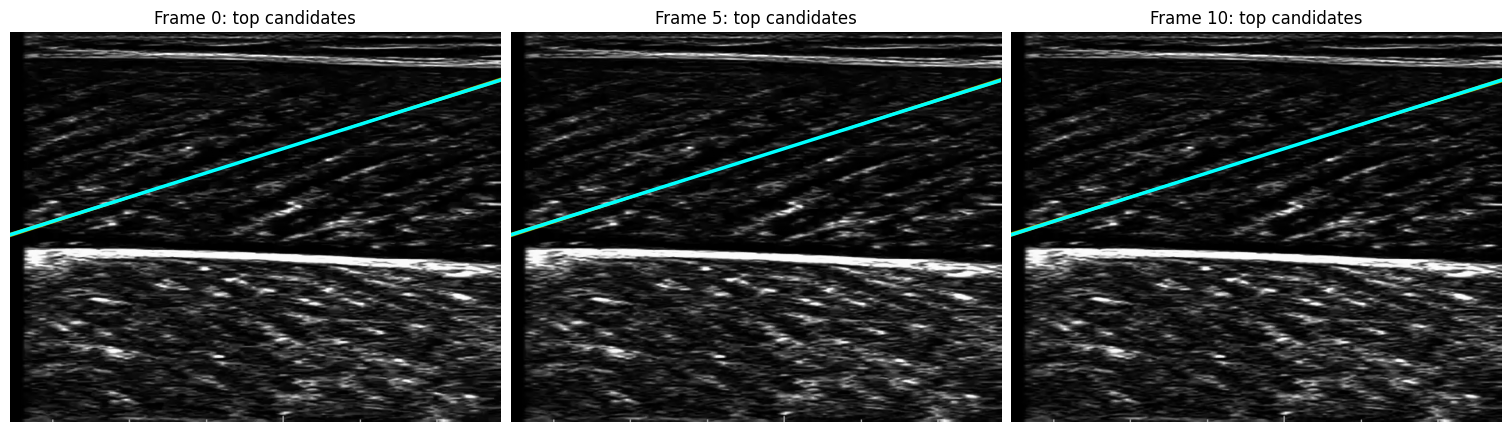

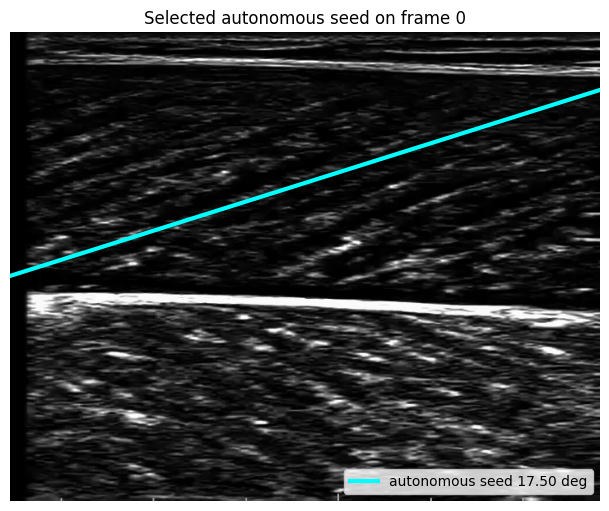

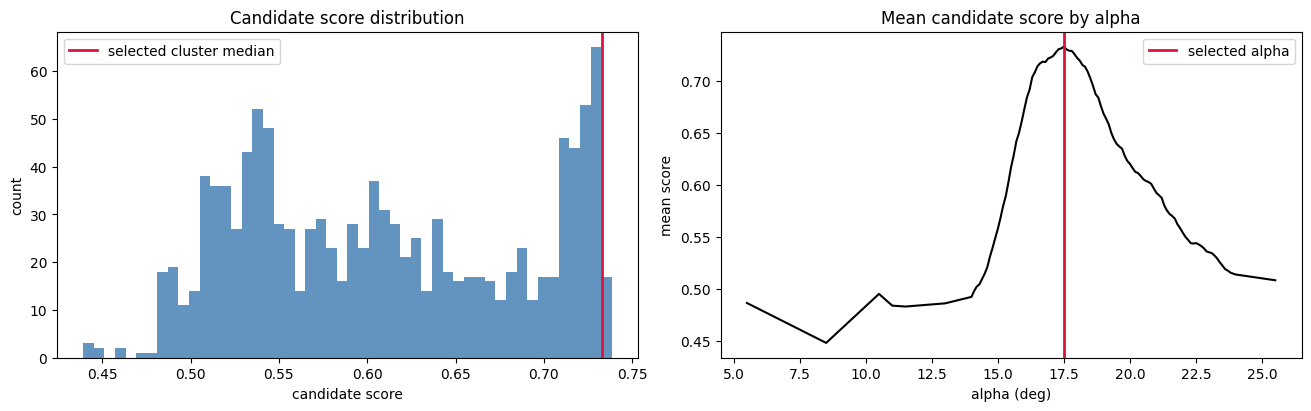

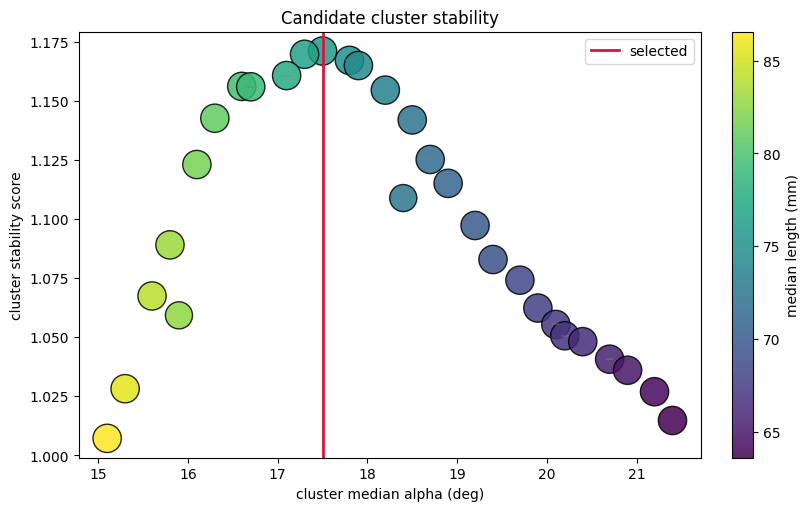

In [8]:
def draw_segment(ax, segment, *, color="lime", lw=2.0, label=None, alpha=1.0):
    x1, y1, x2, y2 = np.asarray(segment, dtype=float).reshape(4)
    ax.plot([x1 - 1, x2 - 1], [y1 - 1, y2 - 1], color=color, lw=lw, label=label, alpha=alpha)

# Candidate lines overlaid on first frames.
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
for ax, frame_idx in zip(axes, [0, 5, 10]):
    ax.imshow(seed_frames[frame_idx], cmap="gray")
    frame_candidates = candidates_with_clusters[candidates_with_clusters["frame"] == frame_idx].sort_values("score", ascending=False).head(8)
    for _, row in frame_candidates.iterrows():
        seg = [row.x_sup, row.y_sup, row.x_deep, row.y_deep]
        draw_segment(ax, seg, color="yellow", lw=1.0, alpha=0.45)
    selected_members = selection["per_frame_best"][selection["per_frame_best"]["frame"] == frame_idx]
    for _, row in selected_members.iterrows():
        draw_segment(ax, [row.x_sup, row.y_sup, row.x_deep, row.y_deep], color="cyan", lw=2.5, label="selected cluster")
    ax.set_title(f"Frame {frame_idx}: top candidates")
    ax.set_xlim(0, image_width_px)
    ax.set_ylim(image_height_px, 0)
    ax.axis("off")
fig.savefig(OUT / "candidate_lines_first_frames.png", dpi=180)
plt.show()

# Selected seed on frame 0.
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
ax.imshow(seed_frames[0], cmap="gray")
draw_segment(ax, selected_seed, color="cyan", lw=3.0, label=f"autonomous seed {selected_alpha:.2f} deg")
ax.legend(loc="lower right")
ax.set_title("Selected autonomous seed on frame 0")
ax.set_xlim(0, image_width_px)
ax.set_ylim(image_height_px, 0)
ax.axis("off")
fig.savefig(OUT / "selected_autonomous_seed_frame0.png", dpi=180)
plt.show()

# Candidate score distribution and score by alpha.
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].hist(candidates_with_clusters["score"], bins=50, color="steelblue", alpha=0.85)
axes[0].axvline(selection["per_frame_best"]["score"].median(), color="crimson", lw=2, label="selected cluster median")
axes[0].set_title("Candidate score distribution")
axes[0].set_xlabel("candidate score")
axes[0].set_ylabel("count")
axes[0].legend()

alpha_summary = candidates_with_clusters.groupby("alpha_deg", as_index=False)["score"].mean()
axes[1].plot(alpha_summary["alpha_deg"], alpha_summary["score"], color="black", lw=1.5)
axes[1].axvline(selected_alpha, color="crimson", lw=2, label="selected alpha")
axes[1].set_title("Mean candidate score by alpha")
axes[1].set_xlabel("alpha (deg)")
axes[1].set_ylabel("mean score")
axes[1].legend()
fig.savefig(OUT / "candidate_score_distribution.png", dpi=180)
plt.show()

# Cluster stability plot.
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
plot_clusters = clusters.head(30).copy()
size = 30 + 35 * plot_clusters["frame_coverage"]
scatter = ax.scatter(
    plot_clusters["median_alpha_deg"],
    plot_clusters["cluster_score"],
    s=size,
    c=plot_clusters["median_length_mm"],
    cmap="viridis",
    edgecolor="black",
    alpha=0.85,
)
ax.errorbar(
    plot_clusters["median_alpha_deg"],
    plot_clusters["cluster_score"],
    xerr=plot_clusters["alpha_std_deg"].fillna(0),
    fmt="none",
    ecolor="gray",
    alpha=0.4,
)
ax.axvline(selected_alpha, color="crimson", lw=2, label="selected")
ax.set_xlabel("cluster median alpha (deg)")
ax.set_ylabel("cluster stability score")
ax.set_title("Candidate cluster stability")
ax.legend()
fig.colorbar(scatter, ax=ax, label="median length (mm)")
fig.savefig(OUT / "cluster_stability.png", dpi=180)
plt.show()

## Final MATLAB Evaluation

Only from this point onward do we load MATLAB result outputs. This section evaluates the already-computed strict Python autonomous pipeline.

In [9]:
from ultrasound_tracker.matlab_compat import extract_final_region_arrays, load_matlab_result, metric_row

MATLAB_RESULT = ROOT / "data" / "matlab" / "slow_low_2.mat"
matlab_final = extract_final_region_arrays(load_matlab_result(MATLAB_RESULT))

n_eval = min(n_full, len(matlab_final["length_mm"]))

def metrics(reference, estimate, name: str) -> dict:
    row = metric_row(name, np.asarray(reference, dtype=float)[:n_eval], np.asarray(estimate, dtype=float)[:n_eval])
    return row

metric_rows = [
    metrics(matlab_final["length_mm"], autonomous_result["FL_mm"], "final_FL_mm"),
    metrics(matlab_final["pennation_deg"], autonomous_result["PEN_deg"], "final_PEN_deg"),
    metrics(matlab_final["fascicle_angle_deg"], autonomous_result["ANG_deg"], "final_ANG_deg"),
    metrics(matlab_final["fascicle_angle_deg"], python_timtrack_alpha, "timtrack_alpha_deg_debug"),
]
metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(OUT / "autonomous_seed_final_metrics.csv", index=False)
metrics_df

,comparison,n,bias,mae,rmse,corr
0,final_FL_mm,2666,-0.535765,1.458316,1.755197,0.985470
1,final_PEN_deg,2666,0.255631,0.722417,0.885362,0.984877
2,final_ANG_deg,2666,0.305317,0.735391,0.893673,0.986479
3,timtrack_alpha_deg_debug,2666,0.469557,1.394878,2.240213,0.915491


In [10]:
# Reuse NB54 calibrated metrics only after autonomous selection/evaluation.
nb54_summary_path = NB54 / "summary.json"
nb54_summary = json.loads(nb54_summary_path.read_text()) if nb54_summary_path.exists() else {}

fl_rmse = float(metrics_df.loc[metrics_df["comparison"] == "final_FL_mm", "rmse"].iloc[0])
pen_rmse = float(metrics_df.loc[metrics_df["comparison"] == "final_PEN_deg", "rmse"].iloc[0])
ang_rmse = float(metrics_df.loc[metrics_df["comparison"] == "final_ANG_deg", "rmse"].iloc[0])
final_pass = bool(fl_rmse < 2.0 and pen_rmse < 1.0 and ang_rmse < 1.0)

variant_comparison = pd.DataFrame([
    {
        "Variant": "NB54 calibrated seed",
        "Seed source": "MATLAB-calibrated",
        "Aponeuroses source": "Python",
        "FL RMSE": nb54_summary.get("calibrated_seed_FL_RMSE_mm", np.nan),
        "PEN RMSE": nb54_summary.get("calibrated_seed_PEN_RMSE_deg", np.nan),
        "ANG RMSE": nb54_summary.get("calibrated_seed_ANG_RMSE_deg", np.nan),
        "Pass": bool(nb54_summary.get("calibrated_seed_passes", False)),
    },
    {
        "Variant": "NB55 autonomous seed",
        "Seed source": "Python-only",
        "Aponeuroses source": "Python",
        "FL RMSE": fl_rmse,
        "PEN RMSE": pen_rmse,
        "ANG RMSE": ang_rmse,
        "Pass": final_pass,
    },
])
variant_comparison.to_csv(OUT / "variant_comparison.csv", index=False)
variant_comparison

,Variant,Seed source,Aponeuroses source,FL RMSE,PEN RMSE,ANG RMSE,Pass
0,NB54 calibrated seed,MATLAB-calibrated,Python,1.766256,0.878618,0.886312,True
1,NB55 autonomous seed,Python-only,Python,1.755197,0.885362,0.893673,True


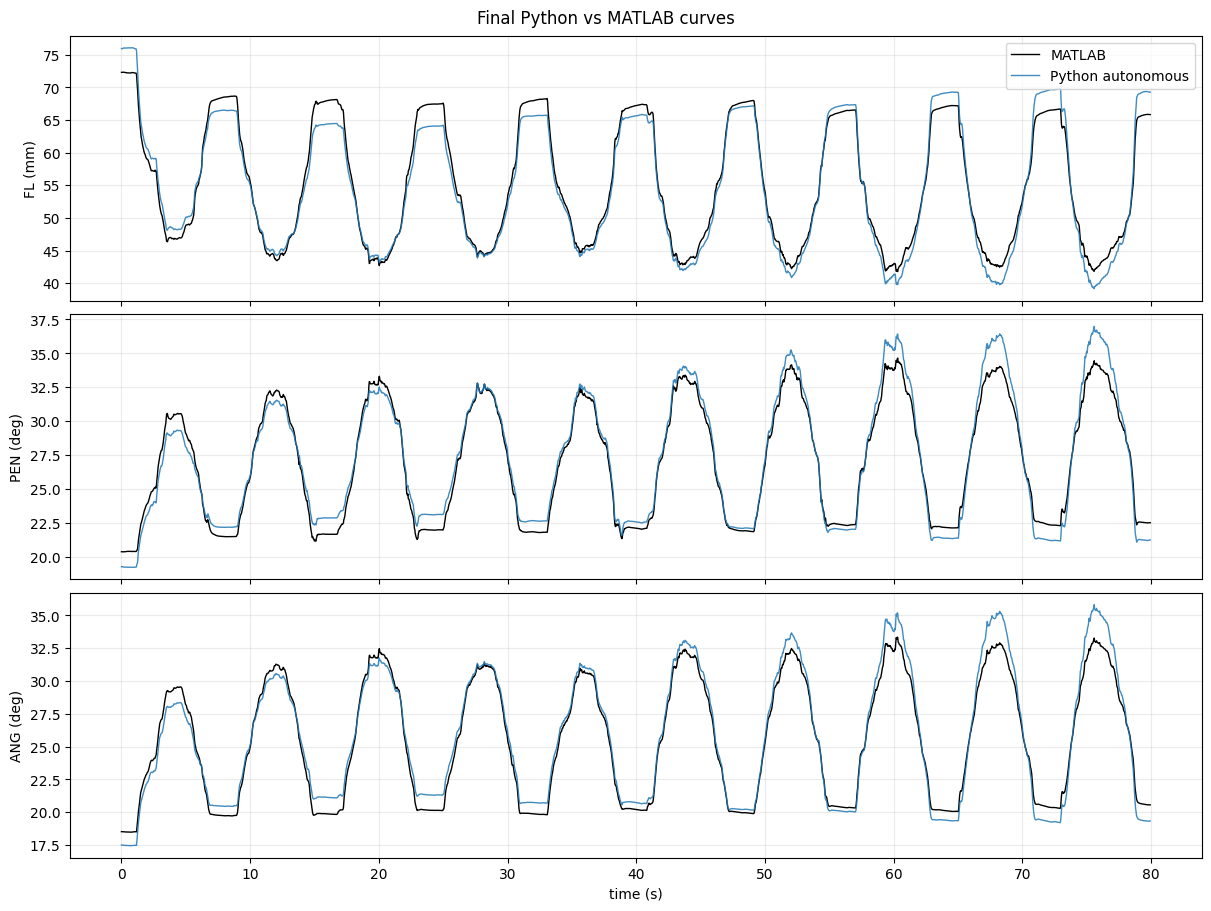

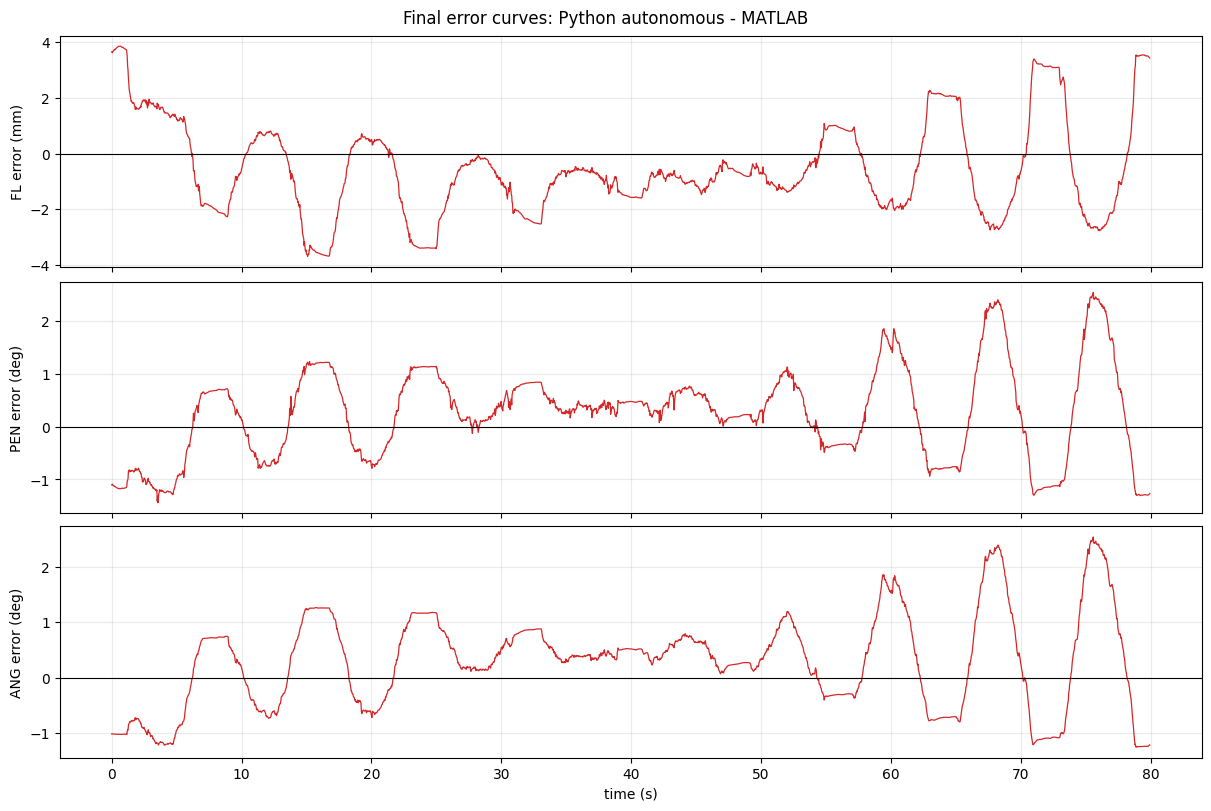

In [11]:
# Final curves and error curves.
time_s = np.asarray(python_tim["time_s"], dtype=float)[:n_eval]
if len(time_s) != n_eval or not np.all(np.isfinite(time_s)):
    time_s = np.arange(n_eval, dtype=float)

series = [
    ("FL", "mm", np.asarray(matlab_final["length_mm"], dtype=float)[:n_eval], autonomous_result["FL_mm"][:n_eval]),
    ("PEN", "deg", np.asarray(matlab_final["pennation_deg"], dtype=float)[:n_eval], autonomous_result["PEN_deg"][:n_eval]),
    ("ANG", "deg", np.asarray(matlab_final["fascicle_angle_deg"], dtype=float)[:n_eval], autonomous_result["ANG_deg"][:n_eval]),
]
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, constrained_layout=True)
for ax, (name, unit, ref, est) in zip(axes, series):
    ax.plot(time_s, ref, color="black", lw=1.0, label="MATLAB")
    ax.plot(time_s, est, color="tab:blue", lw=1.0, alpha=0.85, label="Python autonomous")
    ax.set_ylabel(f"{name} ({unit})")
    ax.grid(True, alpha=0.25)
axes[0].legend(loc="best")
axes[-1].set_xlabel("time (s)")
fig.suptitle("Final Python vs MATLAB curves")
fig.savefig(OUT / "final_python_vs_matlab_curves.png", dpi=180)
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
for ax, (name, unit, ref, est) in zip(axes, series):
    err = est - ref
    ax.plot(time_s, err, color="tab:red", lw=0.9)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel(f"{name} error ({unit})")
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel("time (s)")
fig.suptitle("Final error curves: Python autonomous - MATLAB")
fig.savefig(OUT / "final_error_curves.png", dpi=180)
plt.show()

In [12]:
# Optional full compare script metrics, after MATLAB evaluation boundary.
compare_csv = OUT / "parity_metrics.csv"
cmd = [
    sys.executable,
    str(ROOT / "scripts" / "compare_ultratimtrack_parity.py"),
    "--matlab-result",
    str(MATLAB_RESULT),
    "--python-utt",
    str(autonomous_npz),
    "--python-timtrack",
    str(NB52 / "image_derived_timtrack_geofeatures_arrays.npz"),
    "--video",
    str(VIDEO),
    "--utt-export",
    str(UTT_EXPORT),
    "--out-csv",
    str(compare_csv),
]
print(" ".join(cmd))
run = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True)
print(run.stdout)
if run.stderr:
    print(run.stderr)
if run.returncode != 0:
    raise RuntimeError(f"compare_ultratimtrack_parity.py failed with exit code {run.returncode}")
parity_df = pd.read_csv(compare_csv)
parity_df

/Users/grosbedou/PycharmProjects/NDORMS/.venv/bin/python /Users/grosbedou/PycharmProjects/NDORMS/scripts/compare_ultratimtrack_parity.py --matlab-result /Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_2.mat --python-utt /Users/grosbedou/PycharmProjects/NDORMS/results/notebook55_strict_python_fascicle_seed_selection_gate/strict_python_autonomous_seed_2state_final_arrays.npz --python-timtrack /Users/grosbedou/PycharmProjects/NDORMS/results/notebook52_correct_video_fixed_emask_timtrack_gate/image_derived_timtrack_geofeatures_arrays.npz --video /Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 --utt-export /Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat --out-csv /Users/grosbedou/PycharmProjects/NDORMS/results/notebook55_strict_python_fascicle_seed_selection_gate/parity_metrics.csv


MATLAB result: /Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_2.mat
Python final:  /Users/grosbedou/PycharmProjects/NDORMS/results/notebook55_strict_python_fascicle_seed_selection_gate/strict_python_autonomous_seed_2state_final_arrays.npz
Python TimTrack-like: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook52_correct_video_fixed_emask_timtrack_gate/image_derived_timtrack_geofeatures_arrays.npz
image_depth_mm=50.7
image_height_px=562
image_width_px=706
mm_per_pixel=0.09021352
apox_1b=[20.0, 94.0, 168.0, 242.0, 316.0, 390.0, 464.0, 538.0, 612.0, 686.0]

comparison                                n       bias        mae       rmse     corr
-------------------------------------------------------------------------------------
final_FL_mm                            2666    -0.5358     1.4583     1.7552   0.9855
final_PEN_deg                          2666     0.2556     0.7224     0.8854   0.9849
final_ANG_deg                          2666     0.3053     0.7354     0.893

,comparison,n,bias,mae,rmse,corr
0,final_FL_mm,2666,-0.535765,1.458316,1.755197,0.985470
1,final_PEN_deg,2666,0.255631,0.722417,0.885362,0.984877
2,final_ANG_deg,2666,0.305317,0.735391,0.893673,0.986479
3,timtrack_alpha_deg,2666,0.437734,0.837584,2.010149,0.933033
4,timtrack_phi_vs_python_pen_deg,2666,0.412744,0.891571,2.022837,0.926660
5,timtrack_formula_faslen_px,2666,-10.901087,19.975458,51.213782,0.910619
6,timtrack_gamma_deep_apo_deg,2666,0.049359,0.056801,0.090288,0.983819
7,timtrack_betha_super_apo_deg,2666,0.024990,0.110834,0.230326,0.848307
8,timtrack_super_pos_y1,2666,1.356007,1.607188,2.303977,0.821358
9,timtrack_super_pos_y2,2666,1.048207,1.185294,1.502483,0.885368


## Failure Diagnosis

The diagnosis below is generated after final evaluation. The strict seed-selection rule remains enforced because seed selection was already complete before MATLAB outputs were loaded.

In [13]:
prior_angles = np.asarray([normalized_segment_angle(seg) for seg in autonomous_prior_segments[:n_eval]], dtype=float)
kalman_angles = np.asarray(autonomous_result["ANG_deg"], dtype=float)[:n_eval]
matlab_angles = np.asarray(matlab_final["fascicle_angle_deg"], dtype=float)[:n_eval]

def rmse_np(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    return float(np.sqrt(np.mean((a[mask] - b[mask]) ** 2))) if np.any(mask) else np.nan

prior_angle_rmse_vs_python_alpha = rmse_np(prior_angles, python_timtrack_alpha[:n_eval])
kalman_angle_rmse_vs_prior = rmse_np(kalman_angles, prior_angles)
timtrack_alpha_rmse = float(metrics_df.loc[metrics_df["comparison"] == "timtrack_alpha_deg_debug", "rmse"].iloc[0])
selected_cluster_gap = float(clusters.iloc[0]["cluster_score"] - clusters.iloc[1]["cluster_score"]) if len(clusters) > 1 else np.nan

if final_pass:
    likely_reason = "pass"
    diagnosis_text = (
        "Strict Python autonomous parity is demonstrated on this video: Python selects the initial fascicle prior "
        "without MATLAB target information and reproduces final FL/PEN/ANG within tolerance."
    )
else:
    if fl_rmse >= 2.0 and pen_rmse < 1.0 and ang_rmse < 1.0:
        likely_reason = "seed position or KLT x propagation error"
    elif prior_angle_rmse_vs_python_alpha > 3.0:
        likely_reason = "seed is good candidate but KLT/prior propagation drifts"
    elif kalman_angle_rmse_vs_prior > 2.0:
        likely_reason = "handoff into Kalman is wrong"
    elif np.isfinite(selected_cluster_gap) and selected_cluster_gap < 0.02:
        likely_reason = "multiple anatomically plausible candidate clusters; scoring needs improvement"
    elif timtrack_alpha_rmse > 2.0:
        likely_reason = "TimTrack alpha stream still differs too much"
    else:
        likely_reason = "wrong autonomous seed at frame 0"
    diagnosis_text = (
        "Strict Python autonomous parity is not yet demonstrated. The remaining blocker is "
        f"{likely_reason}, not masks, Hough, aponeurosis tracking, or Kalman."
    )

diagnosis = {
    "selected_alpha_deg": selected_alpha,
    "selected_seed_segment": selected_seed.tolist(),
    "selected_cluster_id": selected_cluster_id,
    "final_pass": final_pass,
    "FL_RMSE_mm": fl_rmse,
    "PEN_RMSE_deg": pen_rmse,
    "ANG_RMSE_deg": ang_rmse,
    "prior_angle_RMSE_vs_python_alpha_deg": prior_angle_rmse_vs_python_alpha,
    "kalman_angle_RMSE_vs_prior_deg": kalman_angle_rmse_vs_prior,
    "timtrack_alpha_RMSE_vs_MATLAB_deg_debug": timtrack_alpha_rmse,
    "selected_cluster_score_gap": selected_cluster_gap,
    "likely_reason": likely_reason,
    "conclusion": diagnosis_text,
    "matlab_used_for_seed_selection": False,
}
(OUT / "diagnosis.json").write_text(json.dumps(diagnosis, indent=2), encoding="utf-8")

summary = {
    "notebook": "55_strict_python_fascicle_seed_selection_gate.ipynb",
    "source_video": str(VIDEO),
    "seed_selection_frames": SEED_FRAME_COUNT,
    "seed_selection_uses_matlab_targets": False,
    "selected_alpha_deg": selected_alpha,
    "selected_seed_segment": selected_seed.tolist(),
    "selected_cluster_id": selected_cluster_id,
    "autonomous_final_npz": str(autonomous_npz),
    "parity_metrics_csv": str(compare_csv),
    "final_pass": final_pass,
    "FL_RMSE_mm": fl_rmse,
    "PEN_RMSE_deg": pen_rmse,
    "ANG_RMSE_deg": ang_rmse,
    "diagnosis": likely_reason,
}
(OUT / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

pd.DataFrame([diagnosis]).to_csv(OUT / "diagnosis.csv", index=False)
display(pd.DataFrame([diagnosis]))
display(Markdown("### Conclusion\n\n" + diagnosis_text))

,selected_alpha_deg,selected_seed_segment,selected_cluster_id,final_pass,FL_RMSE_mm,PEN_RMSE_deg,ANG_RMSE_deg,prior_angle_RMSE_vs_python_alpha_deg,kalman_angle_RMSE_vs_prior_deg,timtrack_alpha_RMSE_vs_MATLAB_deg_debug,selected_cluster_score_gap,likely_reason,conclusion,matlab_used_for_seed_selection
0,17.5,"[754.4759874269765, 55.93546571284381, -48.475...",a17.50_x350_l75,True,1.755197,0.885362,0.893673,3.583061,2.526851,2.240213,0.001373,pass,Strict Python autonomous parity is demonstrate...,False


### Conclusion

Strict Python autonomous parity is demonstrated on this video: Python selects the initial fascicle prior without MATLAB target information and reproduces final FL/PEN/ANG within tolerance.